In [1]:
r"""
Uncertainty quantification with PnP-ULA - CT Example.
====================================================================================================

This code shows you how to use sampling algorithms to quantify uncertainty of a reconstruction
from incomplete and noisy measurements.

ULA obtains samples by running the following iteration:

.. math::

    x_{k+1} = x_k +  \alpha \eta \nabla \log p_{\sigma}(x_k) + \eta \nabla \log p(y|x_k)  + \sqrt{2 \eta} z_k

where :math:`z_k \sim \mathcal{N}(0, I)` is a Gaussian random variable, :math:`\eta` is the step size and
:math:`\alpha` is a parameter controlling the regularization.

The PnP-ULA method is described in the paper :footcite:t:`laumont2022bayesian`.
"""

'\nUncertainty quantification with PnP-ULA - CT Example.\n====================================================================================================\n\nThis code shows you how to use sampling algorithms to quantify uncertainty of a reconstruction\nfrom incomplete and noisy measurements.\n\nULA obtains samples by running the following iteration:\n\n.. math::\n\n    x_{k+1} = x_k +  \\alpha \\eta \\nabla \\log p_{\\sigma}(x_k) + \\eta \\nabla \\log p(y|x_k)  + \\sqrt{2 \\eta} z_k\n\nwhere :math:`z_k \\sim \\mathcal{N}(0, I)` is a Gaussian random variable, :math:`\\eta` is the step size and\n:math:`\\alpha` is a parameter controlling the regularization.\n\nThe PnP-ULA method is described in the paper :footcite:t:`laumont2022bayesian`.\n'

In [ ]:
# %pip install deepinv

In [3]:
import deepinv as dinv
from deepinv.utils.plotting import plot
import torch
from deepinv.utils.demo import load_example

In [4]:
# Load image from the internet
# --------------------------------------------
#
# This example uses the Shepp-Logan phantom image with a low resolution of 32x32 pixels.

device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

img_size = 32
x = load_example(
    "SheppLogan.png",
    img_size=img_size,
    grayscale=True,
    resize_mode="resize",
    device=device,
)

img_height, img_width = x.shape[-2:]
assert img_height == img_width, f"This example assumes square images. Got {img_height}x{img_width}."

In [ ]:
# Define forward operator and noise model
# --------------------------------------------------------------
#
# This example uses parallel-beam tomography as the forward operator and Gaussian noise as the noise model.

# Limited-angle CT
angles = torch.linspace(0, 150, steps=60, device=device)  # limited-angle CT
physics = dinv.physics.Tomography(
    img_width=img_width,
    angles=angles,
    # normalize=True,
    normalize=False,  # Normalization uses aten::vdot which is not yet supported on MPS
    adjoint_via_backprop=False,  # adjoint_via_backprop uses aten::grid_sampler_2d_backward which is not yet supported on MPS
    device=device,
)  # parallel-beam CT operator


# Set the global random seed from pytorch to ensure reproducibility of the example.
torch.manual_seed(0)

x0 = torch.randn(1, 1, img_height, img_width)
physics_cpu = dinv.physics.Tomography(
    img_width=img_width,
    angles=angles.to("cpu"),
    normalize=False,  # Normalization uses aten::vdot which is not yet supported on MPS
    adjoint_via_backprop=False,  # adjoint_via_backprop uses aten::grid_sampler_2d_backward which is not yet supported on MPS
    device="cpu",
)
op_norm = physics_cpu.compute_norm(x0, squared=False, verbose=False).item()  # ||A||
print(f"Operator norm ||A|| = {op_norm:.4f}")

sigma = 0.1  # noise level
sigma /= op_norm  # Adjust noise level based on operator norm
print(f"Adjusted noise level sigma = {sigma:.4f}")
physics.noise_model = dinv.physics.GaussianNoise(sigma=sigma)

Operator norm ||A|| = 43.0799
Adjusted noise level sigma = 0.0023


In [6]:
# Define the likelihood
# --------------------------------------------------------------
#
# Since the noise model is Gaussian, the negative log-likelihood is the L2 loss.
#
# .. math::
#   -\log p(y|x) \propto \frac{1}{2\sigma^2} \|y-Ax\|^2

# load Gaussian Likelihood
likelihood = dinv.optim.data_fidelity.L2(sigma=sigma)

In [7]:
# Define the prior
# -------------------------------------------
#
# The score a distribution can be approximated using Tweedie's formula via the
# :class:`deepinv.optim.ScorePrior` class.
#
# .. math::
#
#            \nabla \log p_{\sigma}(x) \approx \frac{1}{\sigma^2} \left(D(x,\sigma)-x\right)
#
# This example uses a pretrained DnCNN model.
# From a Bayesian point of view, the score plays the role of the gradient of the
# negative log prior
# The hyperparameter ``sigma_denoiser`` (:math:`sigma`) controls the strength of the prior.
#
# In this example, we use a pretrained DnCNN model using the :class:`deepinv.loss.FNEJacobianSpectralNorm` loss,
# which makes sure that the denoiser is firmly non-expansive (see :footcite:t:`terris2020building`), and helps to
# stabilize the sampling algorithm.

sigma_denoiser = 2 / 255
print(f"Using denoiser noise level sigma_denoiser = {sigma_denoiser:.4f}")
prior = dinv.optim.ScorePrior(
    denoiser=dinv.models.DnCNN(
        in_channels=1,
        out_channels=1,
        pretrained="download_lipschitz"
    )
).to(device)

Using denoiser noise level sigma_denoiser = 0.0078


In [8]:
# Create the MCMC sampler
# --------------------------------------------------------------
#
# Here we use the Unadjusted Langevin Algorithm (ULA) to sample from the posterior defined in
# :class:`deepinv.sampling.ULAIterator`.
# The hyperparameter ``step_size`` controls the step size of the MCMC sampler,
# ``regularization`` controls the strength of the prior and
# ``iterations`` controls the number of iterations of the sampler.

regularization = 1e4
step_size = 1e-10
iterations = int(2e4) if (torch.cuda.is_available() or torch.backends.mps.is_available()) else 10
params = {
    "step_size": step_size,
    "alpha": regularization,
    "sigma": sigma_denoiser,
}
f = dinv.sampling.sampling_builder(
    "ULA",
    prior=prior,
    data_fidelity=likelihood,
    max_iter=iterations,
    params_algo=params,
    thinning=1,
    verbose=True,
)

In [9]:
# Generate the measurement
# --------------------------------------------------------------
# We apply the forward model to generate the noisy measurement.

y = physics(x)

100%|██████████| 20000/20000 [00:27<00:00, 733.24it/s]


Iteration 19999, current converge crit. = 9.61E-06, objective = 1.00E-03 
Iteration 19999, current converge crit. = 6.25E-05, objective = 1.00E-03 
Adjoint reconstruction PSNR: -47.79 dB
Posterior mean PSNR: 29.27 dB


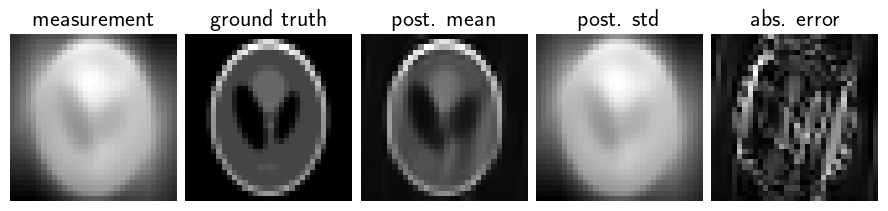

In [10]:
# Run sampling algorithm and plot results
# --------------------------------------------------------------
# The sampling algorithm returns the posterior mean and variance.
# We compare the posterior mean with a simple adjoint reconstruction.

mean, var = f.sample(y, physics)

# compute adjoint
x_lin = physics.A_adjoint(y)

# compute PSNR
print(f"Adjoint reconstruction PSNR: {dinv.metric.PSNR()(x, x_lin).item():.2f} dB")
print(f"Posterior mean PSNR: {dinv.metric.PSNR()(x, mean).item():.2f} dB")

# plot results
error = (mean - x).abs().sum(dim=1).unsqueeze(1)  # per pixel average abs. error
std = var.sum(dim=1).unsqueeze(1).sqrt()  # per pixel average standard dev.
imgs = [x_lin, x, mean, std / std.flatten().max(), error / error.flatten().max()]
plot(
    imgs,
    titles=["measurement", "ground truth", "post. mean", "post. std", "abs. error"],
)

In [11]:
# :References:
#
# .. footbibliography::